In [105]:
import numpy as np
import math
from datetime import datetime
from datetime import timedelta
from Ad import Ad
from AdPoint import AdPoint
import matplotlib.pyplot as plt

In [2]:
class Bidder:

    def __init__(
        self,
        ad,
        cpmMin,
        cpmMax,
        epsilon,
        freq
    ):
        self.__ad      = ad
        self.__cpmMin  = cpmMin
        self.__cpmMax  = cpmMax
        self.__epsilon = epsilon #0.01
        self.__freq    = freq

        
    @property
    def state(self):
        return self.__ad.meta

    def update(self, point):

        self.__ad.update(point)

    def budgetPace(self, touchDate):

        assert isinstance(touchDate, datetime), f"Type error. Tocuh date must be datetime. Use {self.__ad.formatString}"

        pace = self.plan(touchDate=touchDate)

        return self.__ad.meta.get("budgetTotal") * pace

        
    def plan(self, touchDate):

        assert isinstance(touchDate, datetime), f"Type error. Tocuh date must be datetime. Use {self.__ad.formatString}"
        
        startDate, endDate = ( self.__ad.meta.get("startDate"), self.__ad.meta.get("endDate") )

        match self.__freq:
            case 'hour':
                duration = int( (endDate - startDate).total_seconds() / 3600)
                passed   = int( (touchDate - startDate).total_seconds() / 3600)
        
                return passed / duration
            case _:
                duration = (endDate - startDate).total_seconds()
                passed   = (touchDate - startDate).total_seconds()

                return passed / duration

    @property
    def velocity(self):

        startDate, endDate = ( self.__ad.meta.get("startDate"), self.__ad.meta.get("endDate") )
        match self.__freq:
            case 'hour':
                duration = int( (endDate - startDate).total_seconds() / 3600)
            case _:
                duration = 0

        return self.__ad.meta.get("budgetTotal") / duration

    @property
    def roi(self):

        roiInit = self.__ad.meta.get("valuePerClick") * self.__ad.meta.get("click") - \
        self.budgetPace(touchDate=self.__ad.meta.get("touchDate"))

        roiCond = max(0.0001, min(1, roiInit) )

        return roiCond

    @property
    def Ri(self):

        if self.__ad.point == None:
            return None
        else:
            return max(0.0001, min(1, 1 / self.roi) )

    @property
    def Ui(self):
        return self.__ad.meta.get("valuePerClick") * self.__ad.meta.get("ctr")
        

    @property
    def bidPace(self):

        match self.__ad.point != None:
            
            case True:
                budgetPace = self.budgetPace(touchDate=self.__ad.meta.get("touchDate"))
                
                match self.__ad.meta.get("budgetSpent") < budgetPace:
                    case True:
                        #bid =  min(Ri * math.e ** self.__epsilon, 1) 
                        bid = self.Ri * math.e ** self.__epsilon 
                    case _:
                        bid = self.Ri * math.e ** (- self.__epsilon)

                cpmInit = bid * self.Ui * 1000 
                cpmCond = max(self.__cpmMin, min(self.__cpmMax, cpmInit))
                        
                return {
                    'cpmInit'         : cpmInit,
                    'cpmCond'         : cpmCond,
                    'budgetPace'      : budgetPace,
                    'budgetSpent'     : self.__ad.meta.get("budgetSpent"),
                    'budgetDelta'     : budgetPace - self.__ad.meta.get("budgetSpent"),
                    'budgetDeltaShare': round( (budgetPace - self.__ad.meta.get("budgetSpent") ) / budgetPace, 2),
                    'roi'             : self.roi,
                    'bid'             : bid,
                    'Ri'              : self.Ri,
                    'Ui'              : self.Ui
                }
                
            case _:
                return self.__cpmMin


In [167]:
startDate="2026-03-01 08:00:00"
endDate  ="2026-03-10 08:00:00"

Ads = Ad(
    accountId="xxx",
    adId="yyy",
    impression=0,
    click=0,
    budgetSpent=0,
    budgetTotal=1000,
    startDate=startDate,
    endDate=endDate
)



tpoint = AdPoint(
    accountId="xxx",
    adId="yyy",
    impression=1000,
    click =3,
    cpm = 2.3,
    touchDate="2026-03-01 09:00:00"
)

tpoint1 = AdPoint(
    accountId="xxx",
    adId="yyy",
    impression=1100,
    click = 3,
    cpm = 2.5,
    touchDate="2026-03-01 10:00:00"
    
)

tpoint2 = AdPoint(
    accountId="xxx",
    adId="yyy",
    impression=400,
    click = 1,
    cpm = 1.73,
    touchDate="2026-03-01 11:00:00"
    
)

In [158]:
Ads.meta

{'accountId': 'xxx',
 'adId': 'yyy',
 'impression': 0,
 'click': 0,
 'ctr': 0,
 'budgetSpent': 0,
 'budgetRemain': 1000,
 'budgetTotal': 1000,
 'valuePerClick': 1.15,
 'cpm': 0,
 'cpc': 0,
 'startDate': datetime.datetime(2026, 3, 1, 8, 0),
 'endDate': datetime.datetime(2026, 3, 10, 8, 0),
 'touchDate': None}

In [163]:
Ads.update(tpoint)


In [164]:
#Ads.update(tpoint1)

In [165]:
Ads.meta

{'accountId': 'xxx',
 'adId': 'yyy',
 'impression': 2100,
 'click': 6,
 'ctr': 0.002857142857142857,
 'budgetSpent': 5.05,
 'budgetRemain': 994.95,
 'budgetTotal': 1000,
 'valuePerClick': 0.8416666666666666,
 'cpm': 2.4047619047619047,
 'cpc': 0.8416666666666667,
 'startDate': datetime.datetime(2026, 3, 1, 8, 0),
 'endDate': datetime.datetime(2026, 3, 10, 8, 0),
 'touchDate': datetime.datetime(2026, 3, 1, 10, 0)}

In [168]:
bidder = Bidder(ad=Ads, epsilon=0.1, cpmMin=1.2, cpmMax=4, freq='hour')

In [170]:
bidder.update(tpoint1)

In [173]:
bidder.update(tpoint2)

In [171]:
bidder.state

{'accountId': 'xxx',
 'adId': 'yyy',
 'impression': 1100,
 'click': 3,
 'ctr': 0.0027272727272727275,
 'budgetSpent': 2.75,
 'budgetRemain': 997.25,
 'budgetTotal': 1000,
 'valuePerClick': 0.9166666666666666,
 'cpm': 2.5,
 'cpc': 0.9166666666666666,
 'startDate': datetime.datetime(2026, 3, 1, 8, 0),
 'endDate': datetime.datetime(2026, 3, 10, 8, 0),
 'touchDate': datetime.datetime(2026, 3, 1, 10, 0)}

In [174]:
bidder.bidPace

{'cpmInit': 2.5359988666775863,
 'cpmCond': 2.5359988666775863,
 'budgetPace': 13.888888888888888,
 'budgetSpent': 3.442,
 'budgetDelta': 10.446888888888887,
 'budgetDeltaShare': 0.75,
 'roi': 0.0001,
 'bid': 1.1051709180756477,
 'Ri': 1,
 'Ui': 0.0022946666666666666}

In [18]:
Ads.meta

{'accountId': 'xxx',
 'adId': 'yyy',
 'impression': 2100,
 'click': 6,
 'ctr': 0.002857142857142857,
 'budgetSpent': 5.05,
 'budgetRemain': 994.95,
 'budgetTotal': 1000,
 'valuePerClick': 0.8416666666666666,
 'cpm': 2.4047619047619047,
 'cpc': 0.8416666666666667,
 'startDate': datetime.datetime(2026, 3, 1, 8, 0),
 'endDate': datetime.datetime(2026, 3, 10, 8, 0),
 'touchDate': datetime.datetime(2026, 3, 1, 10, 0)}

In [19]:
bidder.bidPace

{'cpmInit': 2.6576729220390574,
 'cpmCond': 2.6576729220390574,
 'budgetPace': 9.25925925925926,
 'budgetSpent': 5.05,
 'budgetDelta': 4.20925925925926,
 'budgetDeltaShare': 0.45,
 'roi': 0.0001,
 'bid': 1.1051709180756477,
 'Ri': 1,
 'Ui': 0.0024047619047619043}

In [94]:
def testRange(t1, t2):

    acc =[]

    startDate = datetime.strptime(t1, "%Y-%m-%d %H:%M:%S")
    endDate   = datetime.strptime(t2  , "%Y-%m-%d %H:%M:%S")

    duration = int( (endDate - startDate).total_seconds() / 3600)

    for i in range(duration):

        current_date = startDate + timedelta(hours=i+1)
        acc.append(current_date)
        
    return acc

class Synthetic:

    def __init__(
        self,
        cpm
    ):
        self.cpm = cpm

    def impression(self, loc=380, scale=50):
        #loc=0, scla=250

        return int( self.cpm * np.random.normal(loc=loc, scale=scale, size=1)[0] )
        
    def click(self, impression, loc=0.025, scale=0.005):

        return int(np.random.normal(loc=loc, scale=scale, size=1)[0] * impression)

    def reward(self):

        impression = self.impression()

        return {
            "cpm":self.cpm,
            "impression": impression,
            "click": self.click(impression=impression)
        }

In [95]:
Synthetic(2.3).reward()

{'cpm': 2.3, 'impression': 890, 'click': 12}

In [103]:
data = []
testPoints = testRange(startDate, endDate)
cpm = 2.3

Ads = Ad(
    accountId="xxx",
    adId="yyy",
    impression=0,
    click=0,
    budgetSpent=0,
    budgetTotal=1000,
    startDate=startDate,
    endDate=endDate
)
bidder = Bidder(ad=Ads, epsilon=0.1, cpmMin=1.2, cpmMax=4, freq='hour')

for i in testPoints:

    synt = Synthetic(cpm).reward()

    testPoint = AdPoint(
        accountId="xxx",
        adId="yyy",
        impression=synt['impression'],
        click =synt['click'],
        cpm = cpm,
        touchDate=i.strftime("%Y-%m-%d %H:%M:%S")
    )

    #Ads.update(testPoint)
    bidder.update(testPoint)
    res = bidder.bidPace
    cpm = res['cpmCond']
    print(f"Date:{i},Spent:{round(res['budgetSpent'], 2)}, Pace:{round(res['budgetPace'], 2)}, CPM:{round( res['cpmCond'], 2)}")
    data.append([i, res['budgetSpent'], res['budgetPace'], res['cpmCond']])

Date:2026-03-01 09:00:00,Spent:1.85, Pace:4.63, CPM:2.54
Date:2026-03-01 10:00:00,Spent:4.26, Pace:9.26, CPM:2.69
Date:2026-03-01 11:00:00,Spent:6.56, Pace:13.89, CPM:2.78
Date:2026-03-01 12:00:00,Spent:9.3, Pace:18.52, CPM:2.86
Date:2026-03-01 13:00:00,Spent:12.58, Pace:23.15, CPM:2.93
Date:2026-03-01 14:00:00,Spent:15.57, Pace:27.78, CPM:2.99
Date:2026-03-01 15:00:00,Spent:19.04, Pace:32.41, CPM:3.04
Date:2026-03-01 16:00:00,Spent:22.57, Pace:37.04, CPM:3.09
Date:2026-03-01 17:00:00,Spent:26.55, Pace:41.67, CPM:3.13
Date:2026-03-01 18:00:00,Spent:29.54, Pace:46.3, CPM:3.16
Date:2026-03-01 19:00:00,Spent:33.21, Pace:50.93, CPM:3.19
Date:2026-03-01 20:00:00,Spent:37.73, Pace:55.56, CPM:3.23
Date:2026-03-01 21:00:00,Spent:42.34, Pace:60.19, CPM:3.26
Date:2026-03-01 22:00:00,Spent:46.96, Pace:64.81, CPM:3.3
Date:2026-03-01 23:00:00,Spent:51.54, Pace:69.44, CPM:3.32
Date:2026-03-02 00:00:00,Spent:56.1, Pace:74.07, CPM:3.35
Date:2026-03-02 01:00:00,Spent:60.75, Pace:78.7, CPM:3.37
Date:202

In [106]:
import pandas as pd

In [108]:
df = pd.DataFrame(data, columns=['date','spent','pace','cpm'])

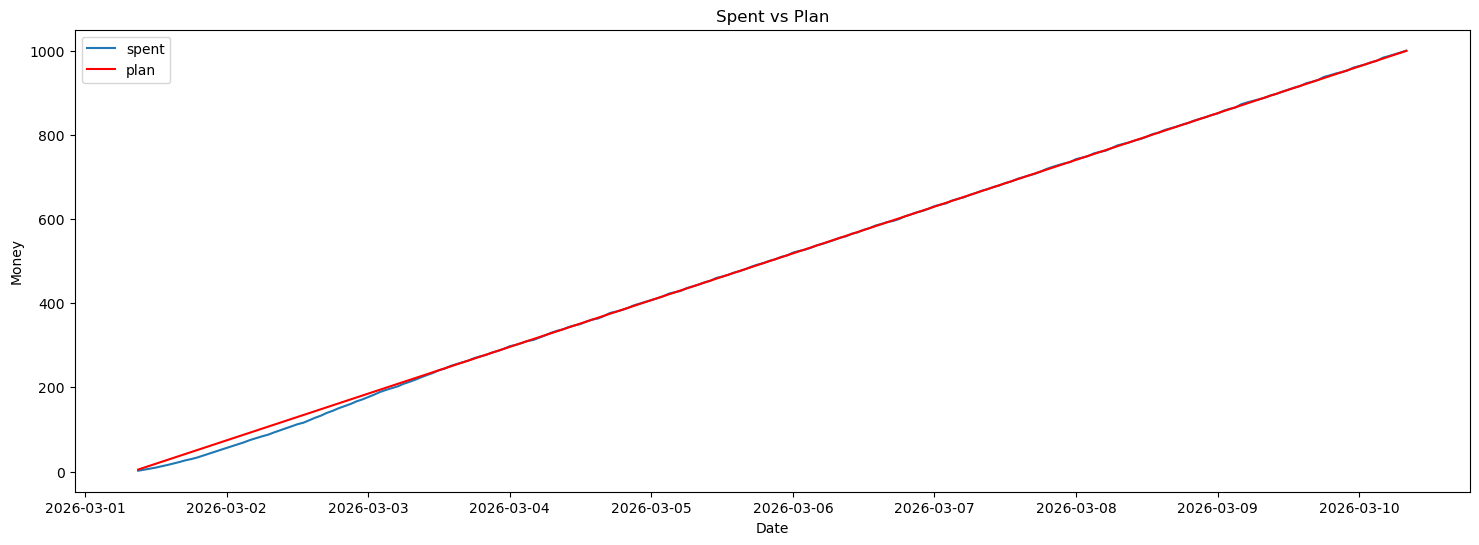

In [136]:
def f(t):
    return np.exp(-t) * np.cos(2*np.pi*t)
    
t1 = np.arange(0.0, 5.0, 0.1)
t2 = np.arange(0.0, 5.0, 0.02)

plt.figure(figsize=(18, 6))
plt.plot(df['date'].values, df['spent'].values, '-', label='spent')
plt.plot(df['date'].values, df['pace'].values, 'r', label='plan')

plt.xlabel("Date")
plt.ylabel("Money")
plt.title("Spent vs Plan")

plt.legend()
plt.show()

/var/folders/sg/pl795q6547d0fxcjnpsfytyx5ytcx4/T/ipykernel_66633/887772144.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax1.plot(df['date'].values, df['pace'].values, 'r', label='plan', color='red')


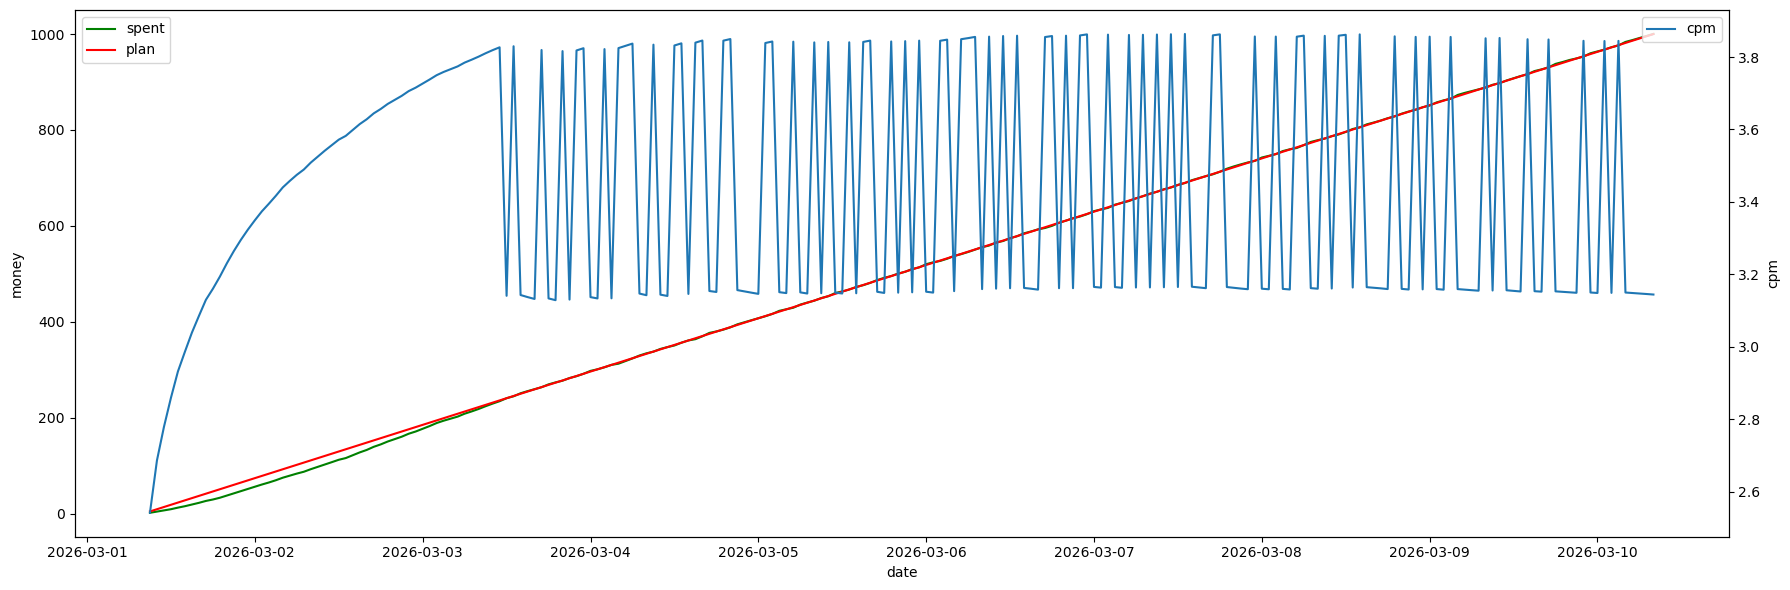

In [156]:
fig, ax1 = plt.subplots(figsize=(18, 6))


ax1.plot(df['date'].values, df['spent'].values, '-', label='spent',color='green')
ax1.plot(df['date'].values, df['pace'].values, 'r', label='plan', color='red')
ax1.set_xlabel('date')
ax1.set_ylabel('money')
plt.legend()

ax2 = ax1.twinx()
ax2.set_ylabel('cpm')
ax2.plot(df['date'].values, df['cpm'].values, label='cpm')
ax2.tick_params(axis='y')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.legend()
plt.show()

In [ ]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('exp', color=color)
ax1.plot(t, data1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('sin', color=color)  # we already handled the x-label with ax1
ax2.plot(t, data2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()